In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib as mpl
from matplotlib.lines import Line2D
from matplotlib.offsetbox import AnchoredText
import numpy as np
from otter import Otter
import syncfit

In [2]:
otterpath = "private-data"
meta = pd.read_csv("ecle-metadata.csv")

private_data = Otter(
    datadir=otterpath,
    gen_summary=True
)

radio = private_data.get_phot(
    names=meta.name.to_list(), 
    obs_type="radio", 
    query_private=True, 
    return_type="pandas",
    flux_unit="mJy",
    freq_unit="GHz"
)

private_data

Attempting to login to https://otter.idies.jhu.edu/api with the following credentials:
username: user-guest
password: test


Unable to apply the source mapping because 'private'
/home/nfranz/.local/lib/lib/python3.12/site-packages/otter/io/transient.py:978: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  for val_av, grp in subset[outdata.corr_av == True].groupby("val_av"):
2020vdq has at least one photometry point where it is unclear if a host subtraction was performed. This can be especially detrimental for UV data. Please consider filtering out UV/Optical/IR or radio rows where the corr_host column is null/None/NaN.
Unable to apply the source mapping because 'private'
/home/nfranz/.local/lib/lib/python3.12/site-packages/otter/io/transient.py:978: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  for val_av, grp in subset[outdata.corr_av == True].groupby("val_av"):
2019qiz has at least one photometry point where it is unclear if a host subtraction was performed. This can be especially detrimental for UV data. Please consider filtering out UV/Optical/

ArangoDB database: otter

In [3]:
def choose_sideband_fullband(df):

    # need same time and same band name
    result = []
    for (t, band), grp in df.groupby(["converted_date", "filter_name"]):

        if len(grp) < 3:
            # this means that it is either full or side band, not both
            for _,row in grp.iterrows():
                result.append(row)
            continue
        
        # now of these we need to choose side band if both are not upperlimits
        # and full band if either (or both) is an upperlimit

        # sorting by the converted_frequency will tell us if it is a sideband or full band
        grp = grp.sort_values("converted_freq").reset_index()

        sideband_low = grp.iloc[0]
        sideband_high = grp.iloc[-1]
        fullband = grp.iloc[1] # assume that each is only three long

        if sideband_low.upperlimit or sideband_high.upperlimit:
            # then append the fullband
            result.append(fullband)
        else:
            result.append(sideband_low)
            result.append(sideband_high)

    res = pd.DataFrame(result).reset_index()
    return res

def make_sed(tde_name, filter_sidebands=True):
    classes = private_data.query(names=tde_name, query_private=True)[0]['classification']
    for c in classes['value']:
        if c['object_class'] in {'AGN', 'TDE'}:
            break
    ecle_class = c['object_class']

    df = radio[radio.name == tde_name]
    if filter_sidebands:
        df = choose_sideband_fullband(df)
    return df

Names have the same score! Just using the existing default_name


SDSS_J0748 {'1': '#332288', '2': '#117733', 'VLASS 1.2': '#44AA99', 'VLASS 2.2': '#CC6677', 'nan': '#DDCC77'}
SDSS_J0748 2
SDSS_J0748
[49794.0, 57458.9162, 57914.71674, 58619.75666, 59542.41444]
SDSS_J0938 {'1': '#332288', '2': '#117733', '3': '#44AA99', 'VLASS 1.1': '#CC6677', 'VLASS 2.1': '#DDCC77', 'VLASS 3.1': '#88CCEE'}
SDSS_J0938 3
SDSS_J0938
[49794.0, 51525.76399999997, 57459.04178, 57911.79545, 58054.46153, 59125.77335, 59961.44979]
SDSS_J1241 {'1': '#332288', '2': '#117733', '3': '#44AA99', 'VLASS 1.2': '#CC6677', 'VLASS 2.2': '#DDCC77', 'nan': '#88CCEE'}
SDSS_J1241 3


Names have the same score! Just using the existing default_name


SDSS_J1241 2
SDSS_J1241
[49794.0, 57459.16642, 57918.05305, 58588.32218, 59545.48532, 60944.95075, 60944.95144, 60944.95214, 60944.95283, 60972.03786, 60972.21166, 60986.12225]
SDSS_J0952 {'1': '#332288', '2': '#117733', 'VLASS 1.2': '#44AA99', 'VLASS 2.2': '#CC6677', 'VLASS 3.2': '#DDCC77', 'nan': '#88CCEE'}


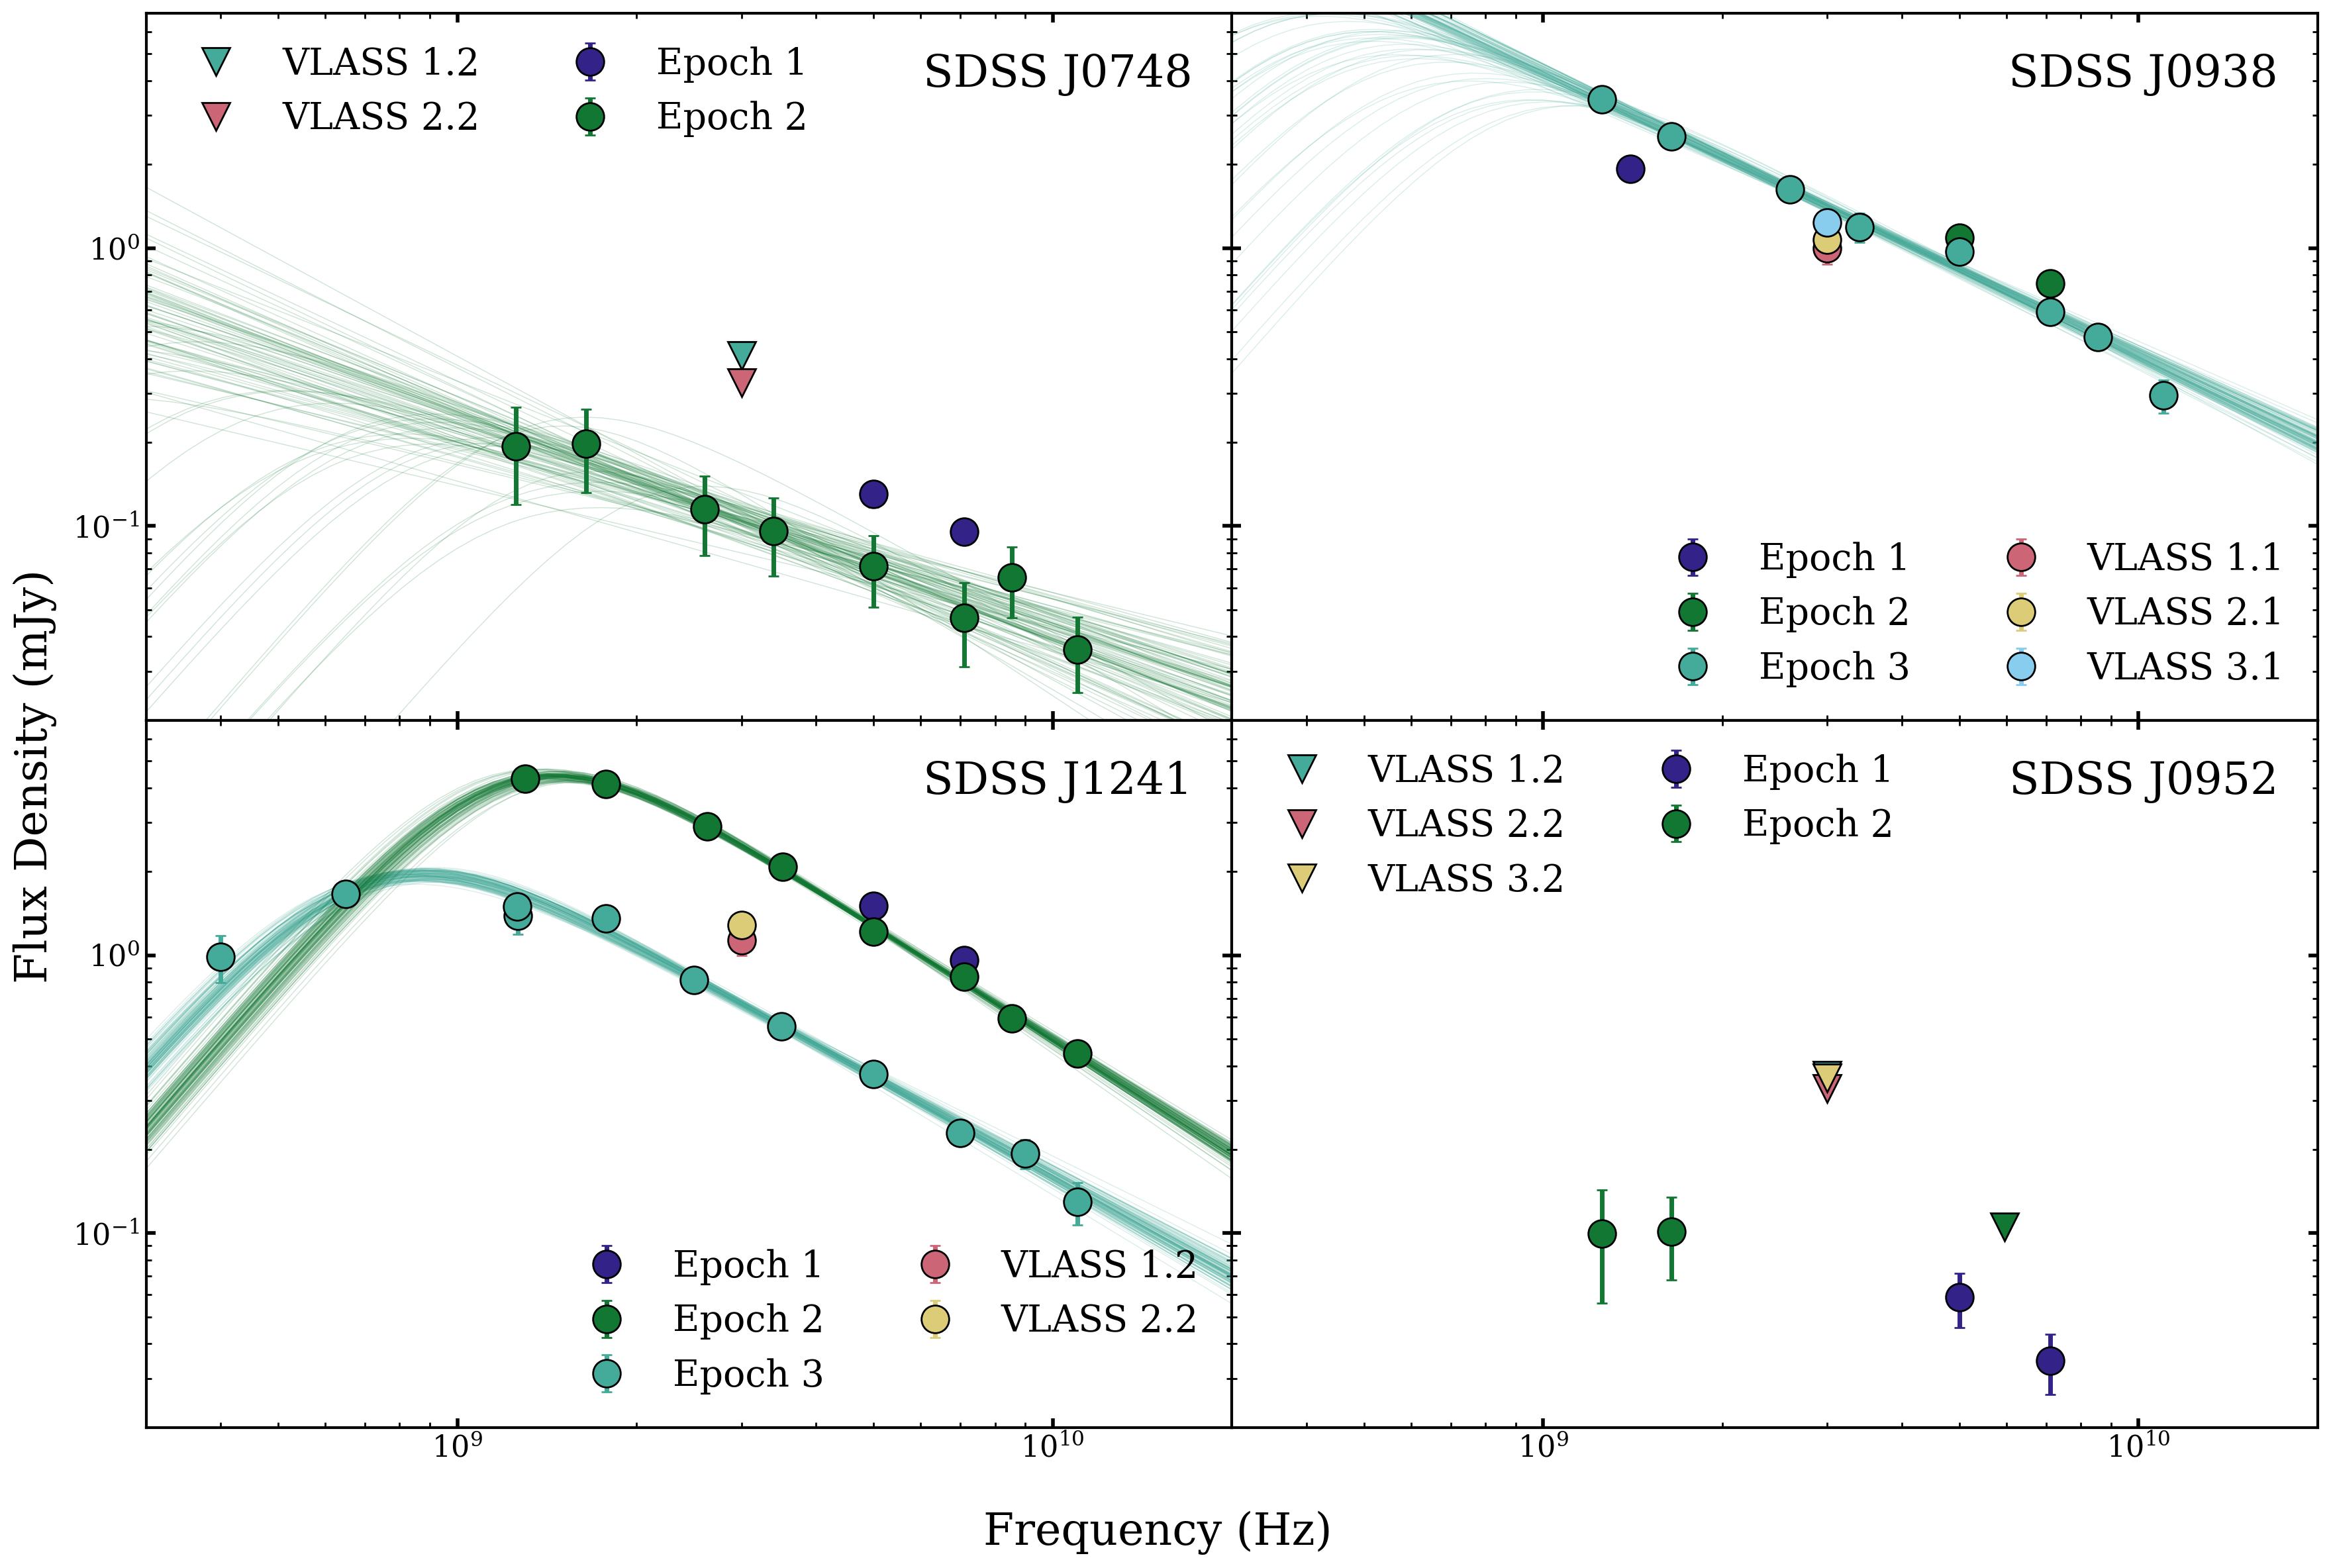

In [4]:
ecles_with_good_seds = ['SDSS_J0748','SDSS_J0938','SDSS_J1241', 'SDSS_J0952']
nkeep = 100

fig, axs = plt.subplots(2,2, figsize=(18,12),sharex=True,sharey=True, gridspec_kw={"wspace":0, "hspace":0})
fig.supylabel("Flux Density (mJy)", fontsize=24)
fig.supxlabel("Frequency (Hz)", fontsize=24)

epoch_map = {
    "SDSS_J0748":{
        49794.0:np.nan, 57458.9162:1, 57914.71674:2, 58619.75666:"VLASS 1.2", 59542.41444:"VLASS 2.2", '57914.0':2
    },
    "SDSS_J0938":{
        49794.0:np.nan, 51525.76399999997:1, 57459.04178:2, 57911.79545:3, 58054.46153:"VLASS 1.1", 59125.77335:"VLASS 2.1", 59961.44979:"VLASS 3.1", '57912.0':3
    },
    "SDSS_J1241":{
        49794.0:np.nan, 57459.16642:1, 57918.05305:2, 58588.32218:"VLASS 1.2", 59545.48532:"VLASS 2.2", 60944.95075:3, 60944.95144:3, 60944.95214:3, 60944.95283:3, 
        60972.03786:3, 60972.21166:3, 60986.12225:3, '60967.0': 3, '57959.0': 2
    },
    "SDSS_J0952":{
        49794.0:np.nan, 57459.29113:1, 57922.76108:2, 58592.0159:"VLASS 1.2", 59549.39139:"VLASS 2.2", 60430.04419:"VLASS 3.2", '57922.5':2
    }
}
import cmasher as cmr
c = [
    '#332288', # Deep Purple/Blue (Dark)
    '#117733', # Green (Medium-Dark)
    '#44AA99', # Teal (Medium)
    '#CC6677',  # Rose/Pink (Medium-Dark)
    '#DDCC77', # Sand/Yellow (Light-Medium)
    '#88CCEE', # Sky Blue (Light)
] #cmr.take_cmap_colors(cmr.dusk, 6, cmap_range=(0,1))

legend_loc_map = {
    "SDSS_J0748":"upper left",
    "SDSS_J0938":"lower right",
    "SDSS_J1241":"lower right",
    "SDSS_J0952":"upper left"
}

for ii, tde_name in enumerate(ecles_with_good_seds):
    df = make_sed(tde_name, filter_sidebands=True)
    emap = epoch_map[tde_name]
    df["epoch"] = df.converted_date.replace(emap)
    
    ax = axs.flatten()[ii]
    color_map = {enum:cc for cc, enum in zip(c, np.unique(list(emap.values())))}
    print(tde_name, color_map)
    for jj, (epoch_num, grp) in enumerate(df.groupby("epoch")):
        lims = grp[grp.upperlimit]
        dets = grp[~grp.upperlimit]

        if isinstance(epoch_num, (int, float)):
            epoch_num = str(int(epoch_num))

        lab = f"Epoch {int(epoch_num)}" if "VLASS" not in epoch_num else epoch_num
        if len(dets):
            ax.errorbar(
                dets.converted_freq*1e9,
                dets.converted_flux,
                yerr = dets.converted_flux_err,
                linestyle = "none",
                marker = "o",
                capsize = 3,
                markersize=15,
                color = color_map[epoch_num],
                mec="k",
                label = lab,
                # alpha = 0.5
            )

        if not len(dets):
            ax.plot(
                lims.converted_freq*1e9,
                lims.converted_flux,
                linestyle = "none",
                marker = "v",
                markersize=15,
                mec="k",
                color = color_map[epoch_num],
                label = lab,
                # alpha = 0.5
            )
        else:
            ax.plot(
                lims.converted_freq*1e9,
                lims.converted_flux,
                linestyle = "none",
                marker = "v",
                markersize=15,
                mec="k",
                color = color_map[epoch_num],
                # alpha = 0.5
            )

    # read in the fit results
    chain_file = f"{tde_name.replace("_","")}-radio-chains.json"
    with open(chain_file, "r") as j:
        chain_dict = json.load(j)

    at = AnchoredText(f'{tde_name.replace("_", " ")}', 'upper right', frameon=False, prop=dict(fontsize=24))
    ax.add_artist(at)
    ax.set_yscale("log")
    ax.set_xscale("log")
    ax.legend(ncols=2, loc=legend_loc_map[tde_name], fontsize=20)

    if tde_name == "SDSS_J0952": continue

    # plot the results over the SEDs
    nu_plot = np.logspace(8,11,100)
    model = syncfit.models.B5()
    for mjd_mean, chain in chain_dict.items():
        epoch_num = emap[mjd_mean]
        if isinstance(epoch_num, (int, float)):
            epoch_num = str(int(epoch_num))
        print(tde_name, epoch_num)
        chain = np.asarray(chain)
        toplot = chain[-nkeep:]
        for val in toplot:
            packed_theta = model.pack_theta(val)       
            res = model.SED(nu_plot, **packed_theta)
    
            ax.plot(nu_plot, res,
                    '-', color=color_map[epoch_num], lw = 0.5, alpha = 0.2)
    
    print(tde_name)
    print(list(sorted(df.converted_date.unique())))

ax.set_ylim(2e-2, 7e0)
ax.set_xlim(3e8, 2e10)

fig.savefig("good-radio-seds-with-fits.png")